In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [5]:
sales_data = pd.read_csv("sales_data.csv")

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


<h1> Converting Date</h1>

In [10]:
sales_data["Date"] = pd.to_datetime(sales_data["Date"])
sales_data = sales_data.sort_values("Date")
sales_data.info()

In [12]:
sales_data["Date"].min(), sales_data["Date"].max(), sales_data["Date"].nunique()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-30 00:00:00'), 760)

<h2>Observations per date check</h2>

In [14]:
obs_per_date = sales_data.groupby("Date").size()
obs_per_date.describe()

count    760.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64

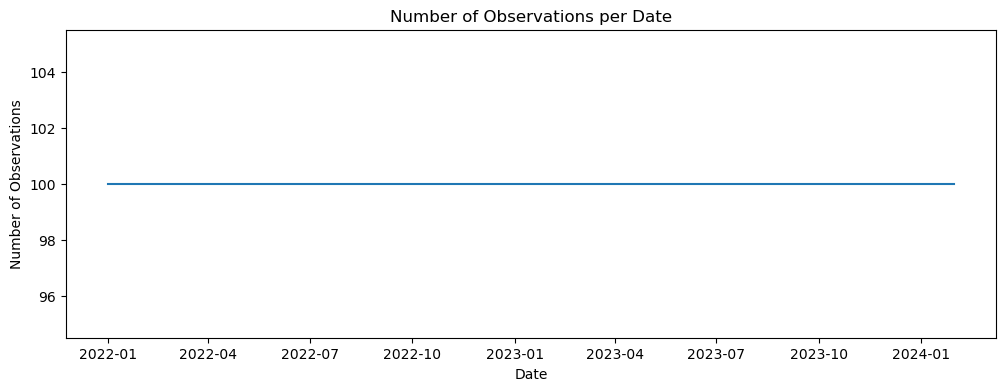

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(obs_per_date.index, obs_per_date.values)
plt.title("Number of Observations per Date")
plt.xlabel("Date")
plt.ylabel("Number of Observations")
plt.show()

<h2> Further data cleaning</h2>

In [26]:
sales_data[["Store ID", "Product ID", "Category", "Region"]].nunique()
sales_data["series_id"] = sales_data["Store ID"].astype(str) + "_" + sales_data["Product ID"].astype(str)
sales_data[["Date", "series_id", "Store ID", "Product ID", "Units Sold"]].head()
sales_data["series_id"].nunique()
series_lengths = sales_data.groupby("series_id")["Date"].nunique()
series_lengths.describe()

count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
Name: Date, dtype: float64

All 100 unique time series's have equal length, and do not need to fill forward missing values.

<h2>Duplicate and missing date checks</h2>

In [32]:
sales_data.duplicated().sum()
sales_data.duplicated(subset=["Date", "Store ID", "Product ID"]).sum()
date_range = pd.date_range(start=sales_data["Date"].min(), end=sales_data["Date"].max(), freq="D")
missing_dates = date_range.difference(sales_data["Date"].unique())
missing_dates
len(missing_dates)

0

No missing dates

<h2>Duplicate Records Check</h2>

In [36]:
sales_data.duplicated().sum()

Store ID
['S001' 'S002' 'S003' 'S004' 'S005']

Product ID
['P0001' 'P0002' 'P0003' 'P0004' 'P0005' 'P0006' 'P0007' 'P0008' 'P0009'
 'P0010' 'P0012' 'P0013' 'P0015' 'P0016' 'P0017' 'P0018' 'P0019' 'P0020'
 'P0014' 'P0011']

Category
['Electronics' 'Clothing' 'Groceries' 'Toys' 'Furniture']

Region
['North' 'South' 'East' 'West']

Weather Condition
['Snowy' 'Cloudy' 'Sunny' 'Rainy']

Seasonality
['Winter' 'Spring' 'Summer' 'Autumn']



In [41]:
sales_data.duplicated(subset=["Date", "Store ID", "Product ID"]).sum()

0

In [39]:
missing_summary

,column,missing_count,missing_percentage
0,Date,0,0.0
1,Store ID,0,0.0
2,Product ID,0,0.0
3,Category,0,0.0
4,Region,0,0.0
5,Inventory Level,0,0.0
6,Units Sold,0,0.0
7,Units Ordered,0,0.0
8,Price,0,0.0
9,Discount,0,0.0


No missing or duplicate cells 

<h2>Invalid Numerical Values Check</h2>

In [57]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Promotion",
    "Epidemic",
    "Demand"
]

sales_data[numeric_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Promotion,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,69.454029,0.328947,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,40.943818,0.469834,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,4.290000,0.000000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,32.620000,0.000000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,65.700000,0.000000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,97.932500,1.000000,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,261.220000,1.000000,1.000000,430.000000


In [51]:
zero_check = (sales_data[numeric_cols] == 0).sum().reset_index()
zero_check.columns = ["column", "zero_count"]
zero_check

,column,zero_count
0,Inventory Level,406
1,Units Sold,406
2,Units Ordered,47107
3,Price,0
4,Discount,17126
5,Competitor Pricing,0
6,Epidemic,60800
7,Demand,0


No invalid values

<h2>EDA</h2>

In [55]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Promotion",
    "Epidemic",
    "Demand"
]

sales_data[numeric_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Promotion,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,69.454029,0.328947,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,40.943818,0.469834,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,4.290000,0.000000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,32.620000,0.000000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,65.700000,0.000000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,97.932500,1.000000,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,261.220000,1.000000,1.000000,430.000000


Units sold mean around 88,82, with min of 0 and max of 426. Demand is generally higher than units sold, Inventory level shows substantial variation due to its high sdev. Units ordered have a median of 0, suggesting that at least half of the observations have no new units ordered, maybe showing ordering is not continuous everyday.

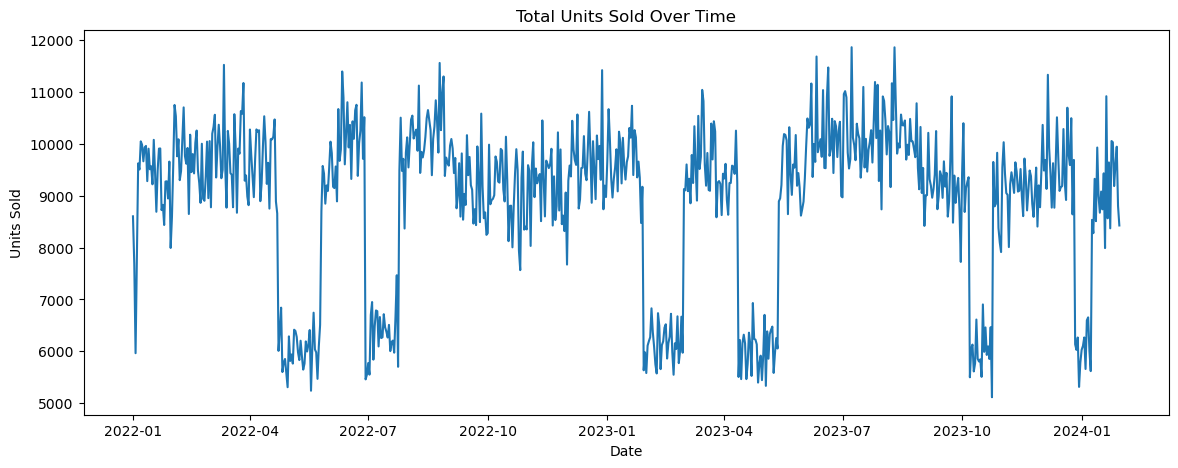

In [60]:
daily_units_sold = sales_data.groupby("Date")["Units Sold"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_units_sold["Date"], daily_units_sold["Units Sold"])
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

The total units sold series shows a clear repeating seasonal pattern, with regular sharp drops followed by recovery across the full horizon. Sales usually fluctuate around 8,500–10,500 units, but fall to around 5,500–6,500 units during low-sales periods. This suggests the data is suitable for time series forecasting because it contains visible seasonality, changing short-term fluctuations, and possible structural/holiday-style effects that should be considered before modelling.

In [63]:
target = "Units Sold"

sales_data[target].agg([
    "mean",
    "std",
    "min",
    "max",
    "skew",
    "kurt"
]).round(3)

mean     88.827
std      43.995
min       0.000
max     426.000
skew      0.790
kurt      1.249
Name: Units Sold, dtype: float64

The positive skewness of 0.790 indicates a right-skewed distribution, meaning occasional high-sales observations are present. The positive kurtosis of 1.249 suggests heavier tails and possible extreme sales spikes, so outlier and seasonality checks are important before forecasting.

<h2>Time series decomposition</h2>

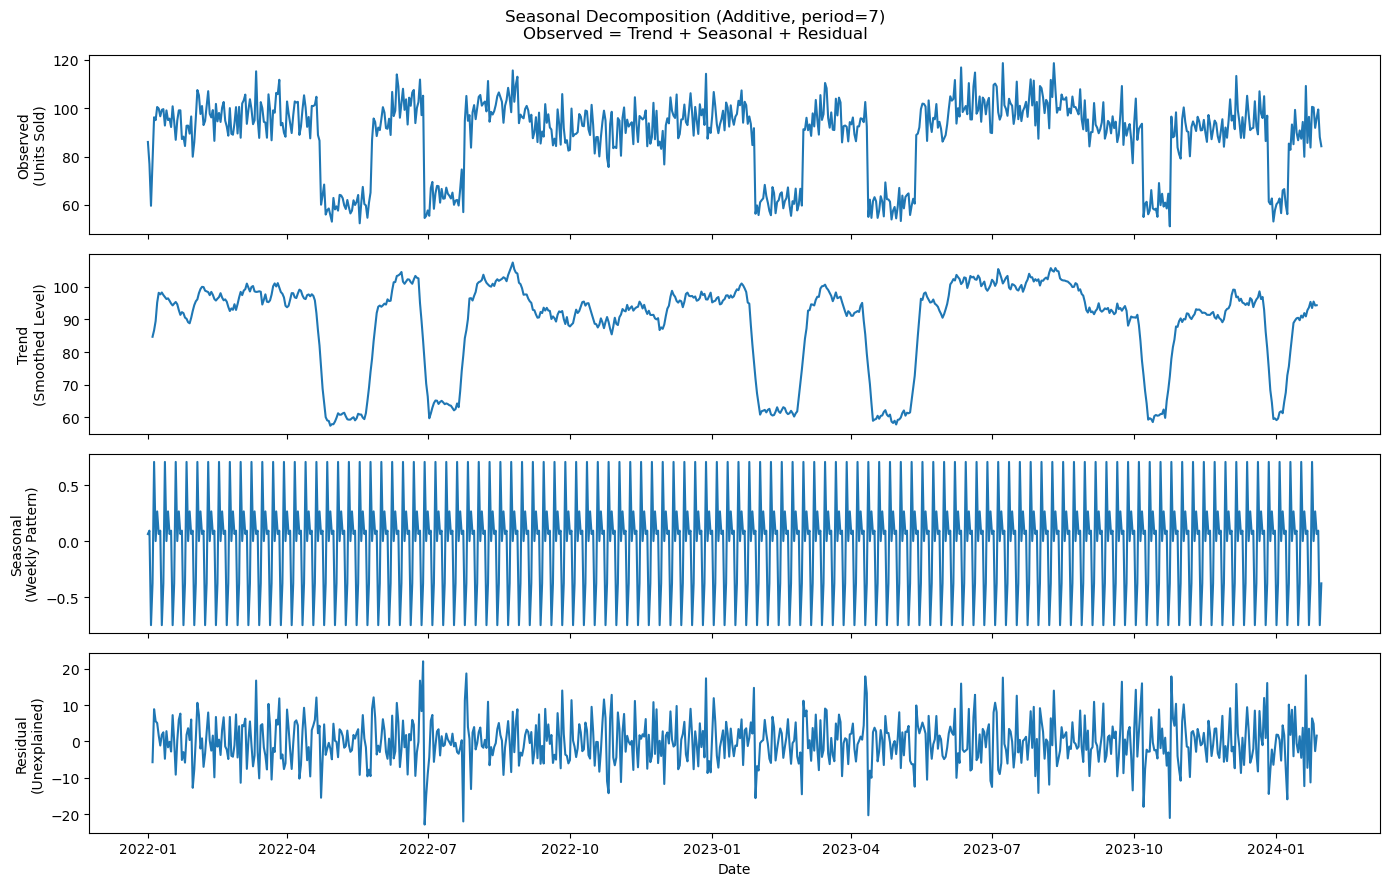

In [88]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_avg_units_sold = sales_data.groupby("Date")["Units Sold"].mean()
daily_avg_units_sold = daily_avg_units_sold.asfreq("D")

decomposition = seasonal_decompose(
    daily_avg_units_sold,
    model="additive",
    period=7
)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

fig.suptitle(
    "Seasonal Decomposition (Additive, period=7)\nObserved = Trend + Seasonal + Residual",
    fontsize=12
)

axes[0].plot(decomposition.observed)
axes[0].set_ylabel("Observed\n(Units Sold)")

axes[1].plot(decomposition.trend)
axes[1].set_ylabel("Trend\n(Smoothed Level)")

axes[2].plot(decomposition.seasonal)
axes[2].set_ylabel("Seasonal\n(Weekly Pattern)")

axes[3].plot(decomposition.resid)
axes[3].set_ylabel("Residual\n(Unexplained)")

axes[3].set_xlabel("Date")

plt.tight_layout()
plt.show()

<h2>ACF and PACF</h2>

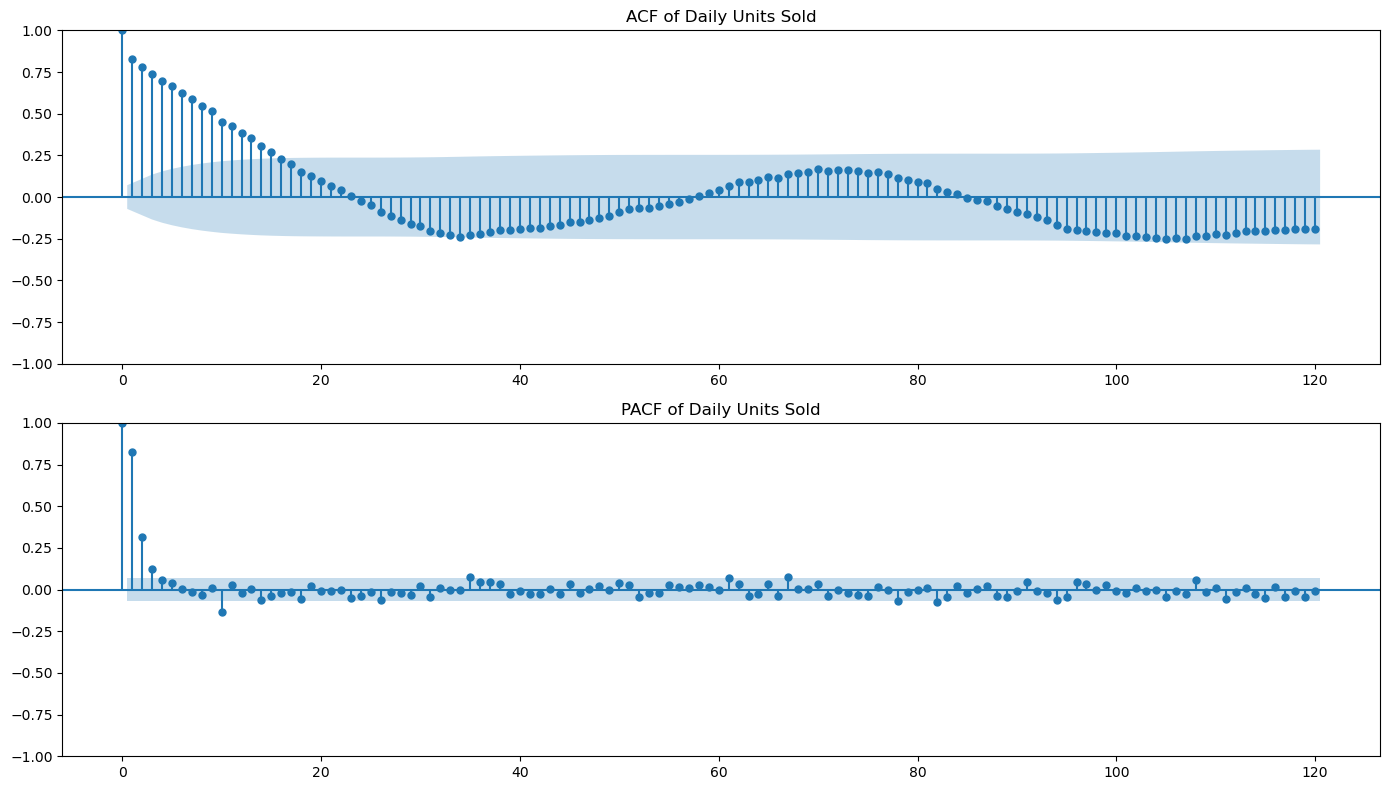

In [74]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_units_sold, lags=120, ax=axes[0])
axes[0].set_title("ACF of Daily Units Sold")

plot_pacf(daily_units_sold, lags=120, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Daily Units Sold")

plt.tight_layout()
plt.show()

The ACF shows a slow, wave-like decay, which means Units Sold has strong time dependence and is not behaving like random noise. The repeated rise and fall pattern also suggests a seasonal or cyclical structure in the sales series. Because the ACF does not cut off quickly, the original series is likely not fully stationary and may require differencing or seasonal modelling.

The PACF shows a large significant spike at lag 1 and a smaller spike around lag 2, then most later lags become much weaker. This suggests that recent sales values, especially the previous day, are important for explaining current sales. In QBUS3850 terms, this supports considering AR-style components, especially low-order AR terms.

Overall, the ACF/PACF results suggest that Units Sold has strong autocorrelation, possible seasonality, and non-stationary behaviour, so forecasting models should not treat observations as independent. Models such as ARIMA/SARIMA, exponential smoothing, or models with seasonal components would be more suitable than a simple static average model.

<h3>Further 'outlier' detection</h3>

In [80]:
q1 = daily_units_sold.quantile(0.25)
q3 = daily_units_sold.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = daily_units_sold[(daily_units_sold < lower_bound) | (daily_units_sold > upper_bound)]

outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Number of Outliers",
        "Outlier Percentage",
        "Minimum Outlier",
        "Maximum Outlier"
    ],
    "Value": [
        q1,
        q3,
        iqr,
        lower_bound,
        upper_bound,
        outliers.shape[0],
        outliers.shape[0] / daily_units_sold.shape[0] * 100,
        outliers.min() if outliers.shape[0] > 0 else None,
        outliers.max() if outliers.shape[0] > 0 else None
    ]
})

outlier_summary["Value"] = outlier_summary["Value"].round(3)
outlier_summary

,Metric,Value
0,Q1,8524.000
1,Q3,9926.500
2,IQR,1402.500
3,Lower Bound,6420.250
4,Upper Bound,12030.250
5,Number of Outliers,122.000
6,Outlier Percentage,16.053
7,Minimum Outlier,5117.000
8,Maximum Outlier,6417.000


The outlier check identifies 122 outlier days, which is about 16.05% of the daily sales observations. Using the IQR rule, normal daily sales are expected to fall between 6,420.25 and 12,030.25 units. The detected outliers range from 5,117 to 6,417 units, meaning all outliers are low-sales outliers, not unusually high-sales spikes.

This matches the earlier time series plot, where Units Sold had repeated sharp drops. This also suggests the outliers are likely not random data errors, but recurring low-sales periods caused by seasonality, promotions, inventory shortages, epidemic effects, or other external conditions. Therefore, they should not be automatically removed; they should be treated as meaningful sales shocks or seasonal low-demand periods for forecasting.